Dog species classification problems

In [ ]:
import matplotlib.pyplot as plt
dach_length = [55,57,64,63,58,49,54,61]
dach_height = [30,31,36,30,33,25,37,34]
jin_length  = [56,47,56,46,49,53,52,48]
jin_height  = [52,52,50,53,50,53,49,54]

newdata1 = [[59,35]]
newdata2 = [[53,54]]

plt.scatter(dach_length,dach_height,c='r',label='Dachshund')
plt.scatter(jin_length, jin_height, c='b',marker='^',label='Jindo dog')
plt.scatter(newdata1[0][0], newdata1[0][1], c='g',marker='x',label='Unknown1')
plt.scatter(newdata2[0][0], newdata2[0][1], c='g',marker='x',label='Unknown2')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Dog size')
plt.legend(loc='upper right')

In [2]:
import numpy as np

d_data = np.column_stack((dach_length,dach_height))
d_label = np.zeros(len(d_data))

j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))

dogs   = np.concatenate([d_data, j_data])
labels = np.concatenate([d_label,j_label])

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm = Pipeline([('scaler',StandardScaler()),
                ('linearSVC',LinearSVC(C=1,loss='hinge'))])
svm.fit(dogs,labels)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linearSVC', LinearSVC(C=1, loss='hinge'))])

In [4]:
print(svm.named_steps['linearSVC'].coef_)
print(svm.named_steps['linearSVC'].intercept_)
print(svm.named_steps['scaler'].transform(dogs))

w=svm.named_steps['linearSVC'].coef_
b=svm.named_steps['linearSVC'].intercept_
dt=svm.named_steps['scaler'].transform(dogs)

w[0,0]
b

[[-0.16879197  1.27575095]]
[0.03118748]
[[ 0.13882344 -1.15746348]
 [ 0.50901929 -1.05947716]
 [ 1.80470477 -0.56954552]
 [ 1.61960685 -1.15746348]
 [ 0.69411722 -0.8635045 ]
 [-0.97176411 -1.64739511]
 [-0.04627448 -0.4715592 ]
 [ 1.249411   -0.76551818]
 [ 0.32392137  0.9982357 ]
 [-1.34195996  0.9982357 ]
 [ 0.32392137  0.80226305]
 [-1.52705788  1.09622203]
 [-0.97176411  0.80226305]
 [-0.23137241  1.09622203]
 [-0.41647033  0.70427672]
 [-1.15686203  1.19420835]]


array([0.03118748])

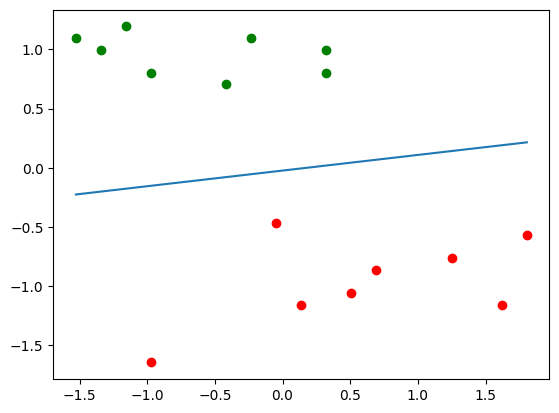

In [5]:
x=np.linspace(np.min(dt[:,0]),np.max(dt[:,0]))
y = -(w[0,0]/w[0,1])*x - b/w[0,1]
plt.plot(x,y)

plt.scatter(dt[:8,0],dt[:8,1],c='r')
plt.scatter(dt[8:,0],dt[8:,1],c='g')

In [6]:
print(svm.predict(newdata1))
print(svm.predict(newdata2))

[0.]
[1.]


Iris dataset

In [7]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets (default is 75% training and 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Initialize a StandardScaler object and scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM classifier and train the model using the scaled training data
svm_classifier = SVC(kernel='linear')  # Kernel can be changed to 'linear', 'poly', 'rbf', etc.
svm_classifier.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = svm_classifier.predict(X_test_scaled)

# Calculate and print the classification accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy: {accuracy:.2f}")

Classification accuracy: 0.97


Classification accuracy: 0.84


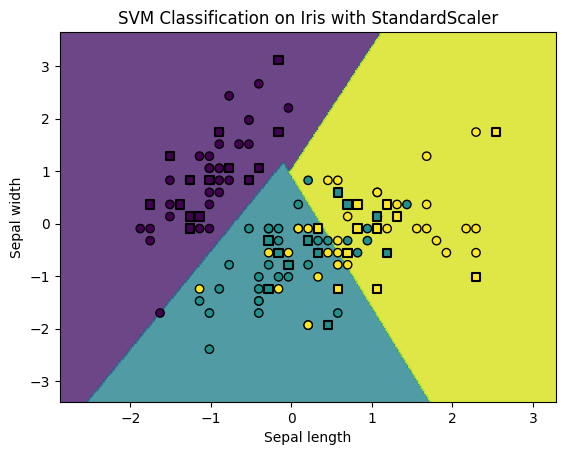

In [9]:
#for visualization, 2 variables are used.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Only take the first two features for visualization
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = svm_classifier.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy: {accuracy:.2f}")

# Create a mesh to plot in
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot decision boundaries
Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8)

# Plot also the training points
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, marker='o', edgecolors='k')
# Plot the testing points
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, marker='s', edgecolors='k', facecolors='none', linewidths=1.5)

plt.title('SVM Classification on Iris with StandardScaler')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

Mesh Grid Definition: A mesh grid (xx, yy) is created over the feature space. np.meshgrid generates two 2D grids for the x-values (xx) and y-values (yy) in the specified range. The range is determined by the minimum and maximum values of the scaled training features. An additional padding of 1 unit is subtracted from the minimum and added to the maximum to extend the area covered by the grid, ensuring that all data points are well within the plot boundaries.

Resolution: The step size of 0.02 dictates the resolution of the grid. Smaller steps result in a finer mesh grid, which allows for a smoother decision boundary visualization but increases computational cost.

Decision Prediction: The SVM classifier predicts the class for each point on the mesh grid. The np.c_ concatenates the raveled xx and yy arrays column-wise (where ravel flattens the arrays), so each point on the grid is classified.
Reshape Output: The prediction result Z is reshaped back to the shape of xx and yy to align with the grid dimensions.

Contour Plot: plt.contourf is used to create a filled contour plot. Each region of the grid is colored based on the predicted class, effectively showing the decision boundaries. The parameter alpha=0.8 controls the transparency of the colors.

Training Points: The training data points are plotted using plt.scatter. The points are colored based on their actual class labels (c=y_train), with solid colors and a black edge (edgecolors='k').

Testing Points: Similarly, test data points are also plotted. These points use a different marker style (marker='s' for square) and are outlined with no fill (facecolors='none'). This helps to distinguish them from the training points, providing a clear visual differentiation between data used for training and testing.

In [10]:
print("Coefficients:", svm_classifier.coef_)
print("Intercept:", svm_classifier.intercept_)

Coefficients: [[-2.03853614  1.08808337]
 [-1.85347496  0.7914668 ]
 [-1.06943902 -0.42802496]]
Intercept: [-1.47549707 -0.81440998  0.39607655]


One-vs-Rest (OvR) Approach
The "One-vs-Rest" strategy involves training one SVM classifier for each class. Each classifier is tasked with distinguishing a specific class (positive class) from all other classes (negative classes). In the case of the Iris dataset, which has three classes, three classifiers are trained:

The first classifier differentiates the first class from the other classes.
The second classifier differentiates the second class from the other classes.
The third classifier differentiates the third class from the other classes.

Interpretation of Coefficients and Intercepts

Coefficients: Each row represents the coefficients of a different SVM classifier. These coefficients define the decision boundary for each classifier, where each row’s coefficients are the weights used by that classifier to differentiate the "positive class" from the "negative classes."
Coefficients of the first classifier: [-2.03853614, 1.08808337]
Coefficients of the second classifier: [-1.85347496, 0.7914668]
Coefficients of the third classifier: [-1.06943902, -0.42802496]

Intercepts: Each intercept adjusts where the decision boundary of each SVM classifier is positioned in the feature space. The intercept values indicate how far the decision boundary is from the origin for each classifier.
Intercept of the first classifier: -1.47549707
Intercept of the second classifier: -0.81440998
Intercept of the third classifier: 0.39607655

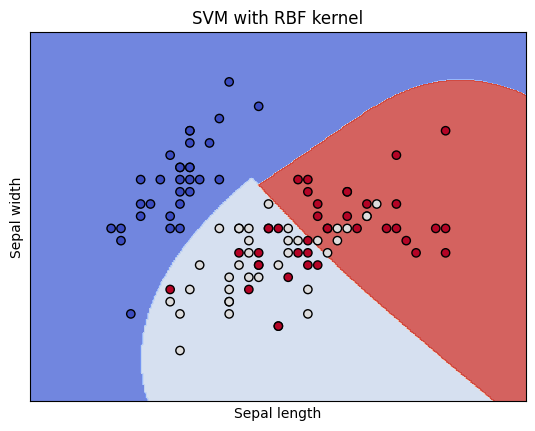

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load data
iris = datasets.load_iris()
X = iris.data[:, :2]  # We take only the first two features for easy visualization.
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set the SVM with RBF kernel
clf = SVC(kernel='rbf', C=100, gamma=0.1)
clf.fit(X_train_scaled, y_train)

# Create a mesh to plot in
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Plot decision boundaries
plt.subplot(1, 1, 1)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot also the training points
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.title('SVM with RBF kernel')

plt.show()

Grid Search

In [12]:
#1 Set Up
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#Grid Search
# Set the parameters by cross-validation
tuned_parameters = [
    {'kernel': ['rbf'], 'gamma': [1e-3, 1e-4], 'C': [1, 10, 100, 1000]},
    {'kernel': ['linear'], 'C': [1, 10, 100, 1000]}
]

# Create a SVC object
svc = SVC()

# Create the GridSearchCV object
clf = GridSearchCV(svc, tuned_parameters, scoring='accuracy', cv=5)

# Perform the search on the scaled training data
clf.fit(X_train_scaled, y_train)

# Print best parameters and best score
print("Best parameters set found on development set:")
print(clf.best_params_)
print("Grid scores on development set:")
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r" % (mean, std, params))


Best parameters set found on development set:
{'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Grid scores on development set:
0.362 (+/-0.114) for {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
0.362 (+/-0.114) for {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
0.895 (+/-0.140) for {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
0.362 (+/-0.114) for {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
0.943 (+/-0.071) for {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
0.895 (+/-0.140) for {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
0.952 (+/-0.085) for {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
0.943 (+/-0.071) for {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
0.943 (+/-0.071) for {'C': 1, 'kernel': 'linear'}
0.952 (+/-0.085) for {'C': 10, 'kernel': 'linear'}
0.952 (+/-0.085) for {'C': 100, 'kernel': 'linear'}
0.952 (+/-0.085) for {'C': 1000, 'kernel': 'linear'}


In [14]:
#evaluation
# Evaluate the best SVM model found by GridSearchCV on the test data
y_true, y_pred = y_test, clf.predict(X_test_scaled)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



- Precision: This metric shows the ratio of correctly predicted positive observations to the total predicted positives for each class. For example, Class 0 has a precision of 1.00, meaning that every instance predicted as Class 0 was indeed Class 0.

- Recall: This metric indicates how well the model can identify each class. A recall of 1.00 for Class 2 means that every actual instance of Class 2 was correctly predicted.

- F1-Score: The harmonic mean of precision and recall. It considers both false positives and false negatives, providing a balance between precision and recall. For instance, Class 1 has an F1-score of 0.96.

- Support: The actual number of occurrences of each class in the dataset. For example, there are 19 instances of Class 0.

- Accuracy: The ratio of correctly predicted observations to the total observations. Here, it is 0.98 or 98%, which shows the overall accuracy of the model.

- Macro Average: This averages the scores (precision, recall, F1-score) for each class without weighting. Each class is treated equally. Macro averages for precision, recall, and F1-score are 0.98, 0.97, and 0.97 respectively. This measure treats all classes equally and provides an average performance metric across all classes.

- Weighted Average: This computes the averages for precision, recall, and F1-score, weighted by the number of true instances for each class. It is useful when dealing with class imbalance. Weighted averages for precision, recall, and F1-score are all 0.98, indicating that the model's predictions are consistently strong across classes with varying support.